<a href="https://colab.research.google.com/github/gbabbar4/rag-with-langchain/blob/main/RAG_Implementation_with_LangChain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Document Loading**

## **Retrieval Augmented Generation**

In retrieval augmented generation (RAG), an LLM retrieves contextual documents from an external dataset as part of its execution.

This is useful if we want to ask question about specific documents (e.g., our PDFs, a set of videos, etc).

In [5]:
!pip install -q langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.57.0 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [3]:
!pip install -q langchain langchain-google-genai python-dotenv

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.6/81.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.5/571.5 kB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 20.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.57.0 which is incompatible.


In [6]:
!pip install pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 385.1/385.1 kB 7.7 MB/s eta 0:00:00


In [1]:
from google.colab import userdata

GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')

In [4]:
# Installing LangChain

# import os # Iska use generally operating system/environment variables ke saath interact karne ke liye hota hai. ----> NOT needed here
# import openai
# import sys
# sys.path.append('../..')

# from dotenv import load_dotenv, find_dotenv
'''
find_dotenv = .env file ko find karta hai.
load_dotenv = .env file mein stored variables ko environment variables mein load karta hai.
'''
# _ = load_dotenv(find_dotenv()) # read local .env file

from langchain_google_genai import ChatGoogleGenerativeAI # Imp for LangChain + Gemini integration

llm = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash", # telling which model we need to use
    google_api_key=GOOGLE_API_KEY # giving in the API Key which is stored in the .env file
)

In [ ]:
# response = llm.invoke("Explain RAG in simple terms")
# print(response.content)

# Output
# [{'type': 'text', 'text': '**RAG** stands for **Retrieval-Augmented Generation**. \n\nIt sounds complicated, but the easiest way to understand it is using the **"Open-Book Exam" analogy**.\n\n---\n\n### The "Open-Book Exam" Analogy\n\nImagine you are taking a tough history test:\n\n* **Standard AI (No RAG) is like taking a *closed-book* exam.** The AI relies *only* on what it memorized during its training. If you ask it a question about something it didn\'t study, or about recent events, it might guess or make up a convincing lie (called a "hallucination").\n* **RAG AI is like taking an *open-book* exam.** Before answering your question, the AI quickly runs to a digital library, finds the exact page with the right information, reads it, and *then* writes a smart answer for you.\n\n---\n\n### How RAG Works in 3 Simple Steps\n\n1. **R - Retrieve:** When you ask a question, the AI searches a specific dataset (like your company\'s private documents, a website, or a database) for relevant facts.\n2. **A - Augment:** The AI takes those facts and combines them with your original question.\n3. **G - Generate:** The AI uses its writing skills to generate a clear, accurate answer based on the facts it just looked up.\n\n---\n\n### Why is RAG so important?\n\nBefore RAG, if you wanted an AI to know your private company files or yesterday\'s news, you had to spend millions of dollars "retraining" the AI. \n\nWith RAG, you don\'t need to retrain the AI. You just hand it a stack of papers and say, *"Read this first, then answer my question."*\n\n**Main Benefits:**\n* **Fewer lies:** The AI bases its answers on real documents you provide.\n* **Up-to-date information:** It can answer questions about what happened five minutes ago, as long as it has access to the data.\n* **Privacy:** Companies can let AI read their secret internal documents without sharing that data with the outside world.', 'extras': {'signature': 'Ep4bCpsbARFNMg/F9gHK1WSSkl+vDIctWmTmT2BBCtsoF2kMWkCk/jIt9ePPXXI7sSgozcpsCohWEf7Or9eq7xpUYCiPndePHOcjCjsNqdkM4hIstOHHaAzGHNBPRw4RLJnMIIV9b0QBulobkL6z75P2Oeclc1PH/sTdHJeQrNe2x2FAUwWJP3N/sADj3dbBsnvxiBfy7eG/5D4jgmJ9gmoNVamFd4FDEYuCpYRk6GPyyUj1vbffbbpE9Kv8rXFVWyxYJ6SnR/3fywPVH1zmKlSnk8+HJ8jC4ViuC6LqIS/fiBASDfc0RM5bMvpUMx+cy7FmXZK0gqASmlXp8neB4AnNAKcxfoMLNYOR27b2WKr5QsSUyNwCnrrZYBGckJITNhnwBHNaVgUgX4sRRyNFanDDBdcjCOvv48aOrtEf0cl2wAp7a9FA3GtUJ+PYwYEY1N6EjFk8xyb6Uvmtcn2iP3fgl4rlAuGcQV2I/5gqw7Qd3uh9xjf/NK4pQ3D/GvC07uIFl07avskAv9IfGeeGSo/tUXBWmkHeTlsFTrNSHWPDA6U04LlK7uNjfXOj/AGEUhxOJUImo9q6IXWeS3EzIA9Szteh6UKSi7Wpr+6REUroTWWAKVg+v+x/3D18XEiT8XSfIiVR52cCRSK3LoLsQfBpy2NSLWosYI04+m5le8Ji8iJoHf5Fk4MFVfg1Z3ntrWoZ/+0qurB7LocBWcKr/rbq7/RvQlmvDM++61tVyIO4IiqlKWEWINDGyZkSlrCv4SmwdOFVc0QesPPwEBjZNOV3E0ORdx+TlBN1I+6eS9A5m3brRTbMeHSa/6uCZbHk+69xrE0sQcxlkYw/iTcI9kQjiMoPwS9tbriaBQJ5AtXYa3ECLXnQezTVik9hqUCaA42D9hkSrbuW257u7d5TNMHFm3BHHUm9j4fzF4y1vx68RvbtwtVCEoMBBz/8UN1o2/HXSxaU3smC8a2Kd3uG0+DAcFslj4wHm5FsmWhQ6u1wdDbHyJ8pOoaqaxeGTMtJx5rzX6oBtpv4v2u5iYcPSvyGkKSLea5CUD9gkEyvaBzSiXZkSx+3B35BrXAk94XAPMOPsmUKdVh0dwm1WmteB/lly3C03DOHDGmolGC3PEUrB+TEm2cXGBXxzjA+mNNvkmF9d9uu5/YzN+xRct+Da8a5uG1++auemgKP2YZIp6ntk++zT9m07vIB5DRiyJN+We5JqNZbnOrB4pQRye84+vI0xp99zZ/fTUNk0Xgf8so7F47kSgIFZcbXFzVvA3jE+hjipvrhjlexCxydIUUWlubFpN5MBwD8MU78oTyb4IsfTqmF7UslazvOdtaVTljw/KCFLKY/nhAhns3JIXKnaHcJujM6wOZUN/QqlZMq6Bh0uS05CLxWZlesqjGT9c4xahl7LDkfEL9VAcZ69BUzTCj6sDmtxyzBa4yXByKnoBcOGz7TTYApMbB8Rby8MwKxEymvihEfh3V1TQY8wrIBAIh19lrlVFClvv0HvCrsNDGOOgYLcj3j/KEB8ppEOtFgSOjOgEEM5xzgzS7sM0zszBJ/oZH14D+CFGsMSCBWDW08bjHKawXaTQM/qWj8knvUas9T/MQSbXPyiCdTWOjq8glRAU0qcm9/+DK4KoXmfFevOAqvrKvbMXgwrN92jh8kbif8BHZOlFjm6CuLyzse461ep80nhqoIcnQA+KbL8fdqMi8JYgbTJfDor0Nj6UVs+0XmHe8FyzaDY8aaPDxA6TJRxntHMLrkszp3yqRDKmkGpPcp0J1LoBqHhgCh1x9Vcwo1K+9+ozPT24LwFwaccz0iO7QwtroC4DOp0TvLoFxzfaDswuoFGdlBBiEo0f59me2UeWV3XkfYyBe894Ib0nrgp7OnEAm6v6n0te23fi5r74k/CoCWQGrHWRyPSBbT+SVzhxDi3h3tziV9DPhDozM7NEnv3IzPIGWhPori3FgUCvAFBBZgmsZdHGzE87AMy++eYksnOJ3Rux4OalmvcaK/FAh6A0Z81dsSsB6hSFZoRLvPOv+LphGyOgGSCej78xAKiBnFR+VTflCTsG/28MNnX9LEPw0a4JlRPk0YT/yzsIR75fv93RoqG01kQ+E1ylWVpU1s4CTAXG7s7eYIOpFTwiTMZJwU2W+jfn4L3CElGgNS7xM+9hpCj+xRA1TAmAEL1lRDDQzzKb8kuTk4/3Ym+NJKEw2DjidFamyqUDP+6Ue2ibewfNWUeNFs+qCRskGrhlb6JL3eL78Iqo/TEuky6WkDLGnsJ7jA6sS/oRtcMsmGDbZpPD99wLHBJfpIaSAwVvyajl3VxTuvpVzrtNVPiV052NBMb+WYOJXbZKhInzexrfa4AKgKTlWUmzVdyQ35LTHOYNzHNsAHgq7jtL1rgB2v8MTh7Wnc1Kn7Yvg89pXE/3cxGiYgNpNCUy2L7nFpIEnHp7yfBwbArfpGTJsD4tdspB26Yu2BVX990ALiYT3IZZArhq1NmN+e4p6y6J2PLxtsBab8pKPuK9VAABQ7AhpyCwaLgrxyCH5S+i0zeT5/eTGKAp1z6JaGgMAjeYTtDflz5TKJ4ED/vf1Qra4nQNXHdYKhghzDzMhqsPgxBFL2lyWfZc70L2x56kImnWRicqWXe7XJriTKXHJTETPXuWlbjD/bPV9CbtC1X9xvUoT1WNQOntXKjRpoLwOAgPv1e7qCcNFhiu5cA0o4YS2C/4VlFYUNXcp4t8C8at0lrTrZk26SkR/iLixl0Lhfq1b5iVsySKHC/LJ5X2ayBdrI64hdYO92ec6g+FiaDy+J+jIpFEvXc9cF4JKK0QHS12HFwSkMUs3Z8f2Dpg2UmfullGOko37oz/30AukRyGIlyxaMBFxaa3DoPZogUBwmUTwx8Cp7Jve6UsoZtLxu8F87vB5HnIbppak+1tGZS9klm1rOgQe10yzkYzuVogvvpXf2eds+Uq2wt7cDNOJkvDHBEpvbF2HGDHfp2h47oqRN2JsmZvZiqFyb/cfJPwgfqkXIBTtb8My6zs85zAiljWOHB1cs8qp1T4dWVB4ay9xodYIyCFZoM3Qj8W7t6iMWyxVXxq+Adg1rb9tb0G1d+7og9MkdMGKZLPeQuHbiRKfQdmqf4nZRb8gI+kIdeHNHN7memydHtxAZG/0TIXK50vwpNIBs/nngSnyH+55ODd2hzj853VRKUAGMwW/CbMol4McA85YGSDbK4AKdkzziCNg2cbYSlVTXDXLYJQuMlzsAvzKMbQCvaC2TsLhtPlNKvnGomaL6XuHGWbUKsDt/mMxN0IpiyzRJft0Uj0upZ7qVvu3WtyHyGyrbCOnvj5kemOQiYo2P73+PCbHdohinXWpyo/gc/agFzzZk6vxT2itLg2uZz/1q/+fh9SOjtGN7VjjGTFcwRJUgbo1Mbko40vdHqGVx7p03dIQadxBbWBkHy+lcDZhkY7/200iu/h+Spb6u8Ah0k/qUaU3eRpqnLu/Xo3bufNHDV7rMiqlr8t3uYtY1dOBCfR4pI4msuqIoxj662EBsQUOn7jDxrvc80QFlmG/Z6lBJbbE35sjxKmGa/bBV4rGSCSu8Q8glgFZJwEHM4KAkHdXFREtn2a6zk84Qgm/zpmhDJ5cHGOKYx71WhhzGbJ3l2ybEtLjsESAl9FmwcwbIArXrLbsjl7Q2P/rCWH6uI2vdlNLjzyxHylQLM1/92AMvpTAPXF0Cy7OAHsKor+9PzKB3iSB9qw05AJ2il6xhPb4lPvgc5YmIAMG0AGzzu6Q7kwP70s2cYZDitO0wQVitVuJBo5sDZNTOC8urggeW/5jAyvnE4C8vyIIq3fjHJr4v6h3lkAhpYlIIwxJuFqfPpnypB5TGSFMja3y/X+JXdncejaOO+FxloUPpnCCmiul6TxvQIzIacgRsl9VN8BMJqHcTKUB7R9tcXvuQnqW83ETXo+H2eY4EoWHK7vWcGPpIMRFlC4BOhIT/R2ag2lVmgilXAOp1ZHakO9st5jyS6Um3pFZmKo0zocBoeIV+KFGm1QP3F/t0un5nLloA7d3Q5lp6s+jAiaz+Ld4tCa2V2+gcYCksK26+bEIE/c42nmkAKs+Y1mXtpY9JOrC9OKeKOWWiS0eJ2KKGyRiVzCDe5qf38tVZK7b9iKdq9/IUz9pMV7toMoUYr66ZMK0aQRysULqAJlbjiCrqHKnYAFQsn/3CbJNL/hs265eD+UyCi6vAt2oo/+ros2qvi5gtoemghwnXI683N5NeWp3YZQMNniWdPv0hhAaVwDMFSGHuHhbXysP+ZeQ42ncfdSB2RN/ATrzK0+GXPjzql+1pigMg095SUcQC802gVZl9L4MDRejC8GJRzlEcHJmageX533khbvNNUDgzrUOeHsSSNGF861WsAOMXEf7iI8cCf7iQSAQRND+IPrKaM7eB65fP53++0CJ2h59TweQRgWRCc9Ff7QQOTr5mv7ZdlnUegyrAZQe5oJWekcrFgkxvMQMduKZA4qYjDIWD4Nu2qJtg9+Wyo9BOQDkocbCPOC7rxyIa0fZ/H8h5ucC3M8h2H3G+N/NEBqYOABQ1A5xXmEPMrQ69ctsQp0NcZhyb63odGAjSM7d5UGwiEmBv1E6HRDDf4+vOd6FHvIqsBh85jXM4hSunRII0Vr0PTXqRohVA'}}]


## **Ingestion Phase**

### **Loading the PDF**

Let's load a PDF transcript from Andrew Ng's famous CS229 course! These documents are the result of automated transcription so words and sentences are sometimes split unexpectedly.

In [7]:
from langchain_community.document_loaders import PyPDFLoader
# PyPDFLoader purpose = PDF file ko read karke uske content ko LangChain ke Document format mein convert karna.

/tmp/ipykernel_162/113175382.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


In [8]:
loader = PyPDFLoader("/content/MachineLearning-Lecture01.pdf")
pages = loader.load()
# .load() means "PDF ko read karo aur uske pages ko LangChain Documents mein convert karke mujhe do."

In [9]:
len(pages) # Number of Pages in the PDF File

22

In [10]:
pages[0] # Prints the Document Object

Document(metadata={'producer': 'Acrobat Distiller 8.1.0 (Windows)', 'creator': 'PScript5.dll Version 5.2.2', 'creationdate': '2008-07-11T11:25:23-07:00', 'author': '', 'moddate': '2008-07-11T11:25:23-07:00', 'title': '', 'source': '/content/MachineLearning-Lecture01.pdf', 'total_pages': 22, 'page': 0, 'page_label': '1'}, page_content='MachineLearning-Lecture01  \nInstructor (Andrew Ng): Okay. Good morning. Welcome to CS229, the machine \nlearning class. So what I wanna do today is just spend a little time going over the logistics \nof the class, and then we\'ll start to talk a bit about machine learning.  \nBy way of introduction, my name\'s Andrew Ng and I\'ll be instructor for this class. And so \nI personally work in machine learning, and I\'ve worked on it for about 15 years now, and \nI actually think that machine learning is the most exciting field of all the computer \nsciences. So I\'m actually always excited about teaching this class. Sometimes I actually \nthink that machine 

In [11]:
pages[0].metadata # Details of the PDF File and the current page

{'producer': 'Acrobat Distiller 8.1.0 (Windows)',
 'creator': 'PScript5.dll Version 5.2.2',
 'creationdate': '2008-07-11T11:25:23-07:00',
 'author': '',
 'moddate': '2008-07-11T11:25:23-07:00',
 'title': '',
 'source': '/content/MachineLearning-Lecture01.pdf',
 'total_pages': 22,
 'page': 0,
 'page_label': '1'}

In [12]:
pages[0].page_content # Displays the content of the current page

'MachineLearning-Lecture01  \nInstructor (Andrew Ng): Okay. Good morning. Welcome to CS229, the machine \nlearning class. So what I wanna do today is just spend a little time going over the logistics \nof the class, and then we\'ll start to talk a bit about machine learning.  \nBy way of introduction, my name\'s Andrew Ng and I\'ll be instructor for this class. And so \nI personally work in machine learning, and I\'ve worked on it for about 15 years now, and \nI actually think that machine learning is the most exciting field of all the computer \nsciences. So I\'m actually always excited about teaching this class. Sometimes I actually \nthink that machine learning is not only the most exciting thing in computer science, but \nthe most exciting thing in all of human endeavor, so maybe a little bias there.  \nI also want to introduce the TAs, who are all graduate students doing research in or \nrelated to the machine learning and all aspects of machine learning. Paul Baumstarck \nworks i

In [13]:
# pages[0].page_label
# This wont work because 'page_label' is included in the metadata , it is a metadata's object and not of Document

### **YouTube**

**Package Used**

- **YoutubeAudioLoader** = YouTube video ka audio download karna. (This does not converts the Audio to Text, it only downloads the Audio)
- **OpenAIWhisperParser** = It is a speech-to-text model. Converts the Audio to Text
- **FileSystemBlobLoader** = local filesystem se downloaded files ko load karta hai.
- **GenericLoader** = loader + parser ko combine/orchestrate karne wala component

In [ ]:
! pip install yt_dlp # YouTube se audio/video download karne ke liye yt_dlp install karega.
! pip install pydub # audio files ko process/manipulate karne ke liye library install karega.

In [ ]:
!pip install -q langchain-community yt-dlp pydub openai-whisper

In [ ]:
# Not Working ,need to work on this code

# from langchain_community.document_loaders.generic import GenericLoader
# from langchain_community.document_loaders.blob_loaders import FileSystemBlobLoader
# from langchain_community.document_loaders.parsers import OpenAIWhisperParser
# from langchain_community.document_loaders.blob_loaders.youtube_audio import YoutubeAudioLoader

# save_dir = "/content/docs/youtube/"
# url = "https://www.youtube.com/watch?v=jGwO_UgTS7I"

# loader = GenericLoader(
#     YoutubeAudioLoader([url], save_dir),   # Fetch audio from YouTube
#     FileSystemBlobLoader(save_dir, glob="*.m4a"),
#     OpenAIWhisperParser()
# )

# docs = loader.load()

### **Document Splitting**

Document Splitting ka purpose hai large documents ko small, meaningful chunks mein todna so that embeddings and retrieval later relevant information ko accurately find kar saken.

In [14]:
from langchain_text_splitters import RecursiveCharacterTextSplitter, CharacterTextSplitter
import numpy as np # For Calculating the Dot Product between the Embeddings

#### **RecursiveCharacterTextSplitter**

Suppose in our document we have 3 paras

- paragraph 1
- paragraph 2
- paragraph 3

and we dont want to split between these paras at random, we need to split according to the values set, by giving the priorities to each seperators

```
Normal Workflow of the Recursive part goes like this

Try paragraph break
       ↓
if chunk still too large
       ↓
Try line break
       ↓
if still too large
       ↓
Try sentence/space
       ↓
if still too large
       ↓
Character level
```
So it tries to preserve the natural structure of the text as much as possible.
That's why it's called **Recursive**.


#### **CharacterTextSplitter**

It basically Splits according to a specified separator.

By default, CharacterTextSplitter commonly uses a separator such as `"\n\n"` (depending on configuration/version), so it behaves differently from the recursive splitter.

In [15]:
chunk_size = 26 # Ek chunk ki maximum target size approximately 26 characters hogi.
chunk_overlap = 4
# Adjacent chunks ke beech 4 characters overlap rakhne ki koshish karo.
# Because agar hum text ko brutally cut kar denge, toh context break ho sakta hai.

r_splitter = RecursiveCharacterTextSplitter(
    chunk_size=chunk_size,
    chunk_overlap=chunk_overlap
)
c_splitter = CharacterTextSplitter(
    chunk_size=chunk_size,
    chunk_overlap=chunk_overlap,
    separator = " "
)

**Example - 1**

In [16]:
l = ["qwertyuioiplkjhgfdsazxcvbnmqazwsxedcrfvtgbyhnujmikpol", "a grbg fbeubf  efbofb efbowufbofehfehofheoufh" , "M A C H I N E Le Arn I N G"]

In [17]:
for i in l:
  print("Recursive Splitter : ", r_splitter.split_text(i))
  print("Character Splitter : ", c_splitter.split_text(i))
  print("#" * 60)

Recursive Splitter :  ['qwertyuioiplkjhgfdsazxcvbn', 'cvbnmqazwsxedcrfvtgbyhnujm', 'nujmikpol']
Character Splitter :  ['qwertyuioiplkjhgfdsazxcvbnmqazwsxedcrfvtgbyhnujmikpol']
############################################################
Recursive Splitter :  ['a grbg fbeubf  efbofb', 'efbowufbofehfehofheoufh']
Character Splitter :  ['a grbg fbeubf efbofb', 'efbowufbofehfehofheoufh']
############################################################
Recursive Splitter :  ['M A C H I N E Le Arn I N G']
Character Splitter :  ['M A C H I N E Le Arn I N G']
############################################################


**Example - 2**

In [18]:
some_text = """When writing documents, writers will use document structure to group content. \
This can convey to the reader, which idea's are related. For example, closely related ideas \
are in sentances. Similar ideas are in paragraphs. Paragraphs form a document. \n\n  \
Paragraphs are often delimited with a carriage return or two carriage returns. \
Carriage returns are the "backslash n" you see embedded in this string. \
Sentences have a period at the end, but also, have a space.\
and words are separated by space."""

In [19]:
len(some_text)

496

In [20]:
c_splitter1 = CharacterTextSplitter(
    chunk_size = 100,
    chunk_overlap = 5,
    separator = " "
)

r_splitter1 = RecursiveCharacterTextSplitter(
    chunk_size = 100,
    chunk_overlap = 5,
    separators = ["\n\n", "\n", " ", ""]
)

In [21]:
r_splitter1.split_text(some_text)

['When writing documents, writers will use document structure to group content. This can convey to the',
 "the reader, which idea's are related. For example, closely related ideas are in sentances. Similar",
 'ideas are in paragraphs. Paragraphs form a document.',
 'Paragraphs are often delimited with a carriage return or two carriage returns. Carriage returns',
 'are the "backslash n" you see embedded in this string. Sentences have a period at the end, but',
 'but also, have a space.and words are separated by space.']

In [22]:
c_splitter1.split_text(some_text)

['When writing documents, writers will use document structure to group content. This can convey to the',
 "the reader, which idea's are related. For example, closely related ideas are in sentances. Similar",
 'ideas are in paragraphs. Paragraphs form a document. \n\n Paragraphs are often delimited with a',
 'a carriage return or two carriage returns. Carriage returns are the "backslash n" you see embedded',
 'in this string. Sentences have a period at the end, but also, have a space.and words are separated',
 'by space.']

**Applying the Splitter onto the Original Data**

In [23]:
text_splitter = CharacterTextSplitter(
    chunk_size = 1000,
    chunk_overlap = 150,
    separator = "\n", # NEW LINE
    length_function = len # When we want to decide that how large the chunk should be , we will use the len() function
)

In [24]:
docs = text_splitter.split_documents(pages)

In [25]:
len(docs)

78

In [26]:
docs[0].metadata

{'producer': 'Acrobat Distiller 8.1.0 (Windows)',
 'creator': 'PScript5.dll Version 5.2.2',
 'creationdate': '2008-07-11T11:25:23-07:00',
 'author': '',
 'moddate': '2008-07-11T11:25:23-07:00',
 'title': '',
 'source': '/content/MachineLearning-Lecture01.pdf',
 'total_pages': 22,
 'page': 0,
 'page_label': '1'}

In [27]:
len(pages)

22

**Token-wise Splitting**

In [ ]:
from langchain_text_splitters import TokenTextSplitter

token_splitter = TokenTextSplitter(
    chunk_overlap = 0,
    chunk_size = 1
)

In [ ]:
c_splitter2 = CharacterTextSplitter(
    chunk_overlap = 0,
    chunk_size = 1,
    separator = " "
)

In [ ]:
text = "My Name is Goya, I live in Delhi"
token_splitter.split_text(text)

In the above Output , we can see that some of the text broke down Because `TokenTextSplitter` ko word boundary ki koi obligation nahi hai.
Tokenizer ne "**My**" ko multiple tokens mein represent kiya, so splitter ne usko token boundaries par divide kar diya.

In [ ]:
c_splitter2.split_text(text)

The Reason we encountered a Warning in the above Code output is because we specified that `chunk_size = 1` along with the `separator = " "` which means to split the characs on the basis of whitespaces (" ") as it gives the separator the first priority to seperate the characs..
Additionally , if we notice that there are few words which are longer than 1-character like the words - "Mera" , "naam" , "Goya" etc which are larger than the chunk size specified (1) so thats why it is giving us the warning saying that - "***Created a chunk of size 4, which is longer than the specified 1***"

In [ ]:
token_splitter_data = TokenTextSplitter(
    chunk_overlap = 5,
    chunk_size = 100
)

In [ ]:
split_data = token_splitter_data.split_documents(pages)

In [ ]:
len(split_data)

### **Vector Stores & Embeddings**

#### **Embeddings**



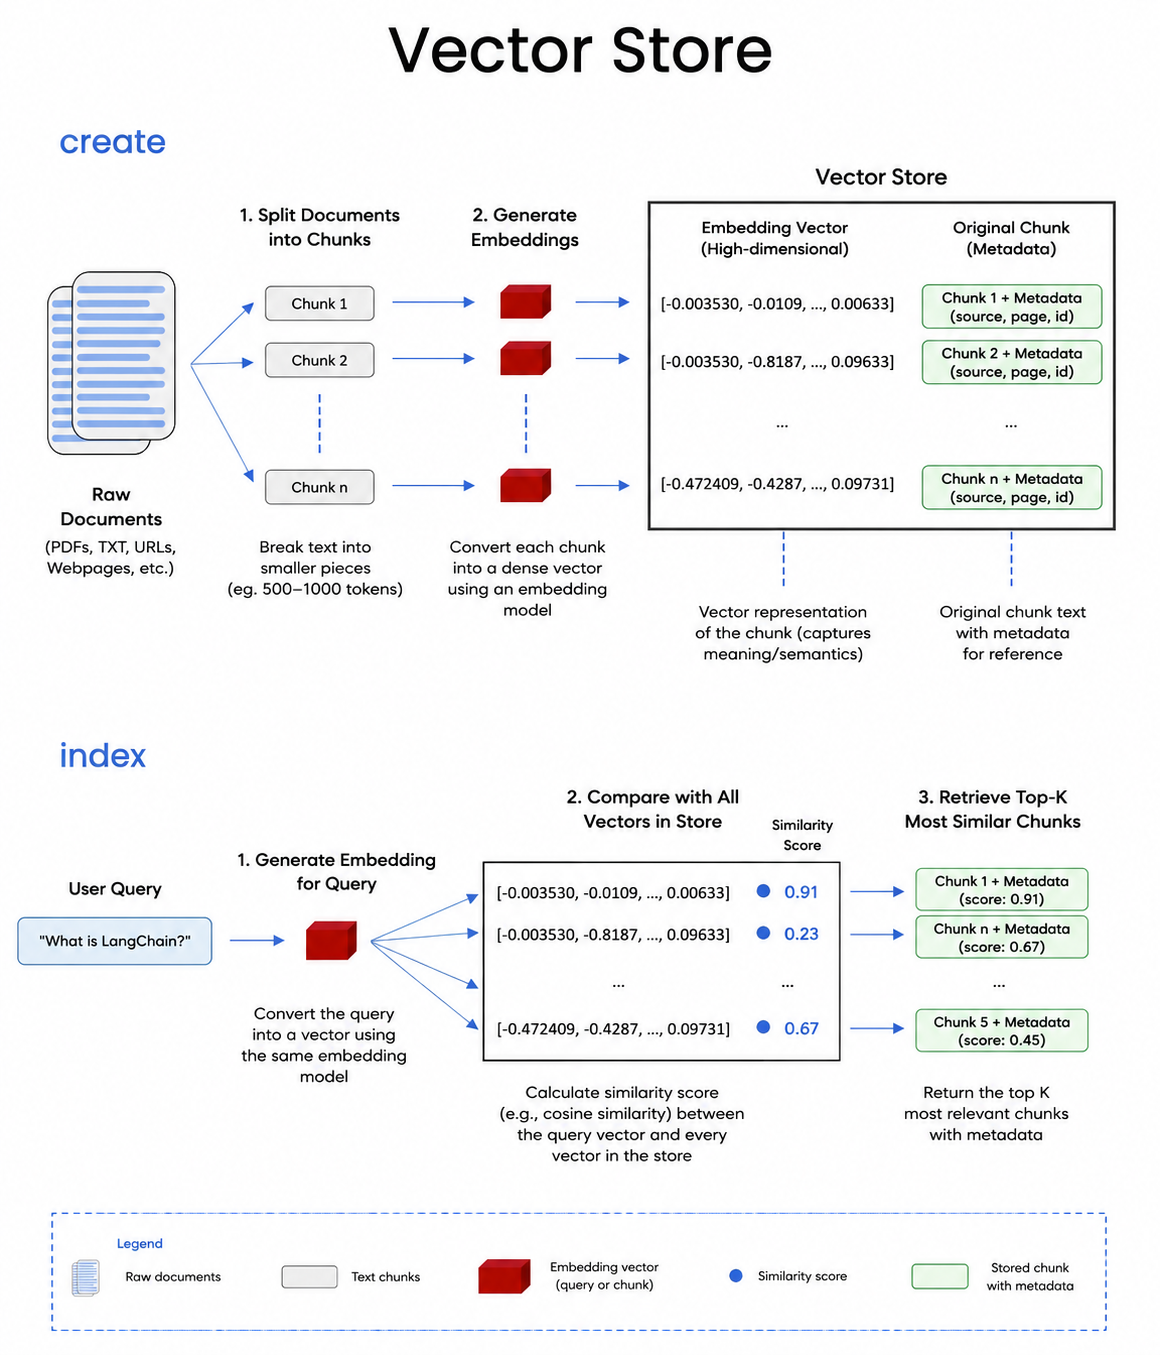

In [28]:
loaders = [
    PyPDFLoader("/content/MachineLearning-Lecture01.pdf"),
    # PyPDFLoader("/content/MachineLearning-Lecture01.pdf"), # Keeping the Duplicate Document so that we can teach the model on handling the Duplicate Files
    PyPDFLoader("/content/MachineLearning-Lecture02.pdf"),
    PyPDFLoader("/content/MachineLearning-Lecture03.pdf"),
]

docs = [] # We will store loaded Documents in this variable
for loader in loaders:
    docs.extend(loader.load())
    # loader.load() loads/reads the data in the PDF File
    # .extend simply extends the data into the docs variable which is given by loader.load()

In [29]:
len(docs) # Total Number of Pages in whole document consisting of all 3 lectures

56

In [30]:
recursive_text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1500,
    chunk_overlap = 150
)

In [31]:
splits = recursive_text_splitter.split_documents(docs) # list of Documents
len(splits)

151

In [32]:
splits[0]

Document(metadata={'producer': 'Acrobat Distiller 8.1.0 (Windows)', 'creator': 'PScript5.dll Version 5.2.2', 'creationdate': '2008-07-11T11:25:23-07:00', 'author': '', 'moddate': '2008-07-11T11:25:23-07:00', 'title': '', 'source': '/content/MachineLearning-Lecture01.pdf', 'total_pages': 22, 'page': 0, 'page_label': '1'}, page_content="MachineLearning-Lecture01  \nInstructor (Andrew Ng): Okay. Good morning. Welcome to CS229, the machine \nlearning class. So what I wanna do today is just spend a little time going over the logistics \nof the class, and then we'll start to talk a bit about machine learning.  \nBy way of introduction, my name's Andrew Ng and I'll be instructor for this class. And so \nI personally work in machine learning, and I've worked on it for about 15 years now, and \nI actually think that machine learning is the most exciting field of all the computer \nsciences. So I'm actually always excited about teaching this class. Sometimes I actually \nthink that machine learn

**Note**: We cannot use the older `models/embedding-001 model`. Since the Gemini API has been updated, this model may no longer be available. For the current Gemini API, we shall use the `gemini-embedding-001` instead for generating text embeddings.

In [ ]:
# from langchain_google_genai import GoogleGenerativeAIEmbeddings

# embeddings = GoogleGenerativeAIEmbeddings(
#     model = "gemini-embedding-001",
#     api_key = GOOGLE_API_KEY
# )

**Examples Input Sentences**

In [ ]:
# sentence1 = "i like dogs"
# sentence2 = "i like canines"
# sentence3 = "the weather is ugly outside"

# embedding1 = embeddings.embed_query(sentence1)
# embedding2 = embeddings.embed_query(sentence2)
# embedding3 = embeddings.embed_query(sentence3)

# Finding the Similarities between different Embeddings:

# print(f"Embedding1 is similar to Embedding2 by a margin of: {round(np.dot(embedding1 , embedding2) * 100 , 2)} %")
# print(f"Embedding1 is similar to Embedding3 by a margin of: {round(np.dot(embedding1 , embedding3) * 100 , 2)} %")
# print(f"Embedding2 is similar to Embedding3 by a margin of: {round(np.dot(embedding2 , embedding3) * 100 , 2)} %")

'''
Output :

Embedding1 is similar to Embedding2 by a margin of: 84.67 %
Embedding1 is similar to Embedding3 by a margin of: 56.0 %
Embedding2 is similar to Embedding3 by a margin of: 56.14 %
''';

**Embeddings Creation of the Lecture Files attached above (*without the duplicate file*)**

In [ ]:
# l = splits[0].page_content
# " ".join(l.split(" "))

In [ ]:
# iter = 5
# l = []

# for i in range(iter):

#   chunk = splits[i].page_content
#   text = " ".join(chunk.split(" "))
#   l.append(text)

# l

# THIS ABOVE VERSION IS CORRECT

In [ ]:
# Creating a list containing the text content of each chunk
split_content = []

for chunk in splits:
    split_content.append(chunk.page_content)

# Now split_content is a list of strings
split_content

In [34]:
split_content[0]

"MachineLearning-Lecture01  \nInstructor (Andrew Ng): Okay. Good morning. Welcome to CS229, the machine \nlearning class. So what I wanna do today is just spend a little time going over the logistics \nof the class, and then we'll start to talk a bit about machine learning.  \nBy way of introduction, my name's Andrew Ng and I'll be instructor for this class. And so \nI personally work in machine learning, and I've worked on it for about 15 years now, and \nI actually think that machine learning is the most exciting field of all the computer \nsciences. So I'm actually always excited about teaching this class. Sometimes I actually \nthink that machine learning is not only the most exciting thing in computer science, but \nthe most exciting thing in all of human endeavor, so maybe a little bias there.  \nI also want to introduce the TAs, who are all graduate students doing research in or \nrelated to the machine learning and all aspects of machine learning. Paul Baumstarck \nworks in mac

In [ ]:
# lecture_files_embeddings = embeddings.embed_documents(split_content)

# giving the `.embed_documents()` a list of strings (split_content)

# did a mistake in using the Gemini API for Embedding and got the following result
# as there was a limited Quota
'''
ClientError: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details.
GoogleGenerativeAIError: Error embedding content (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details.
''';

#### **Change in Approach**

For the **embedding step**, we will not use the Gemini API-based embedding model (`gemini-embedding-001`) because API-based embedding models have usage quotas and rate limits on the Free Tier, which can result in `429 RESOURCE_EXHAUSTED` errors. Instead, we will use a **free, pretrained embedding model** such as `all-MiniLM-L6-v2`, which can run locally in Colab without requiring an API key or consuming API quota. We will use **Gemini through the API during the Generation phase**, where the LLM will take the user's query along with the relevant retrieved chunks and generate the final response.


Nno Gemini API key is involved here. The model is downloaded and runs locally in your Colab environment.

In [ ]:
!pip install -U sentence-transformers langchain-huggingface

In [36]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name = "sentence-transformers/all-MiniLM-L6-v2"
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [37]:
lecture_files_embeddings = embeddings.embed_documents(split_content)
# took 19 seconds to run

In [38]:
len(lecture_files_embeddings)
# Output --> 151 which is same as the len of splits

151

In [39]:
len(lecture_files_embeddings[0])
# Output ---> 384 which is the length of the embeddings of the numerical vectors

384

#### **Vector Stores**

In [ ]:
!pip install -U faiss-cpu langchain-community

In [41]:
from langchain_community.vectorstores import FAISS

In [42]:
vector_store = FAISS.from_embeddings(
    text_embeddings = list(zip(split_content, lecture_files_embeddings)),
    embedding = embeddings
)

##### **Vector Store & `zip()` - Explanation**

After splitting the documents into chunks, each chunk is converted into a numerical vector (embedding) using the `all-MiniLM-L6-v2` embedding model. In our case, there are **151 text chunks**, and therefore we have **151 corresponding embeddings**, with each embedding containing **384 numerical values**. This means that every chunk has exactly one vector representation, and the position of the chunk in `split_content` corresponds to the position of its embedding in `lecture_files_embeddings`.

To store this relationship, we use Python's `zip()` function. `zip(split_content, lecture_files_embeddings)` pairs each complete text chunk with its corresponding embedding - i.e., chunk 0 with embedding 0, chunk 1 with embedding 1, and so on. When we use `[0]` **after** the `zip()` operation, we select the first `(text, embedding)` pair. It is important not to use `split_content[0]` inside `zip()`, because `split_content[0]` is a single string, and Python treats a string as an iterable of individual characters. Similarly, `lecture_files_embeddings[0]` is a single 384-dimensional vector, which is iterable over its individual numbers. Therefore, `zip(split_content[0], lecture_files_embeddings[0])` would incorrectly pair characters of the text with individual numbers from the vector.

The correct structure is therefore:

**Text Chunks -> Corresponding Embeddings -> `(text, embedding)` pairs**

These pairs will then be provided to the **FAISS vector store**, which stores the embeddings and allows us to perform similarity searches. During retrieval, a user's query is also converted into an embedding, and FAISS compares that query vector with the stored vectors to find the chunks that are most semantically similar to the query. These relevant chunks will later be passed to the LLM as context for generating the final answer.

**Overall flow:**

`PDF Documents -> Pages -> Chunks -> Embeddings -> (Chunk, Embedding) Pairs -> FAISS Vector Store -> Similarity Search -> Relevant Chunks -> LLM`


In [43]:
print(type(vector_store))
# <class 'langchain_community.vectorstores.faiss.FAISS'>

<class 'langchain_community.vectorstores.faiss.FAISS'>


Testing query with similarity check score , which will provide the Top k retrieved chunks from the data

In [44]:
query = "what is Machine Learning ?"
results = vector_store.similarity_search(query = query, k = 3)

Printing the Top k (k=3) Text Data from the split data

In [45]:
topk_chunks = []

for i, result in enumerate(results):
    print(f"\n--- Result {i+1} ---")
    print(result.page_content)
    topk_chunks.append(result.page_content)

# topk_chunks


--- Result 1 ---
very excited about the new projector in this room, but I guess we'll see that in operation 
on Wednesday.  
So start by talking about what machine learning is. What is machine learning? Actually, 
can you read the text out there? Raise your hand if the text on the small screens is legible. 
Oh, okay, cool, mostly legible. Okay. So I'll just read it out.  
So what is machine learning? Way back in about 1959, Arthur Samuel defined machine 
learning informally as the [inaudible] that gives computers to learn — [inaudible] that 
gives computers the ability to learn without being explicitly programmed. So Arthur 
Samuel, so way back in the history of machine learning, actually did something very 
cool, which was he wrote a checkers program, which would play games of checkers 
against itself.  
And so because a computer can play thousands of games against itself relatively quickly, 
Arthur Samuel had his program play thousands of games against itself, and over time it 
woul

In [50]:
topk_chunks[0]

'very excited about the new projector in this room, but I guess we\'ll see that in operation \non Wednesday.  \nSo start by talking about what machine learning is. What is machine learning? Actually, \ncan you read the text out there? Raise your hand if the text on the small screens is legible. \nOh, okay, cool, mostly legible. Okay. So I\'ll just read it out.  \nSo what is machine learning? Way back in about 1959, Arthur Samuel defined machine \nlearning informally as the [inaudible] that gives computers to learn — [inaudible] that \ngives computers the ability to learn without being explicitly programmed. So Arthur \nSamuel, so way back in the history of machine learning, actually did something very \ncool, which was he wrote a checkers program, which would play games of checkers \nagainst itself.  \nAnd so because a computer can play thousands of games against itself relatively quickly, \nArthur Samuel had his program play thousands of games against itself, and over time it \nwould 

### **Generation Phase**

In the `.invoke()` function we need to provide the retrived data (chunks) to the LLM in the Generation Phase , which we could copy and then paste the retrived chunk into the LLM input but that is simply not feasible..

So to avoid this , we need to implement the use of **PromptTemplates**

where a **prompt template** consists of a string template. It accepts a set of parameters from the user that can be used to generate a prompt for a language model.

**NOTE** : Prefer using `template_format='f-string'` instead of `template_format='jinja2'`, or make sure to NEVER accept `jinja2` templates from untrusted sources as they may lead to arbitrary Python code execution.

We need to pass data into `.invoke()` function (LLM) like in this format

**Context:**

Chunk 1

Chunk 2

Chunk 3

**Question:**

What is supervised learning?

**Instruction:**

Answer the question using the provided context.

In [51]:
question = "What is Machine Learning ?"

In [52]:
from langchain_core.prompts import PromptTemplate

prompt_template = PromptTemplate.from_template(
    template = "Question : {question} , Context : {topk_chunks}, Prompt : Based on the Context Provided , answer the question and if the answer is not available in the avialable context answer as I DONT KNOW")

print(prompt_template.format(question=question, topk_chunks=topk_chunks))

Question : What is Machine Learning ? , Context : ['very excited about the new projector in this room, but I guess we\'ll see that in operation \non Wednesday.  \nSo start by talking about what machine learning is. What is machine learning? Actually, \ncan you read the text out there? Raise your hand if the text on the small screens is legible. \nOh, okay, cool, mostly legible. Okay. So I\'ll just read it out.  \nSo what is machine learning? Way back in about 1959, Arthur Samuel defined machine \nlearning informally as the [inaudible] that gives computers to learn — [inaudible] that \ngives computers the ability to learn without being explicitly programmed. So Arthur \nSamuel, so way back in the history of machine learning, actually did something very \ncool, which was he wrote a checkers program, which would play games of checkers \nagainst itself.  \nAnd so because a computer can play thousands of games against itself relatively quickly, \nArthur Samuel had his program play thousands

In [55]:
final_prompt = prompt_template.format(question=question, topk_chunks=topk_chunks)

#### **Providing the Input Data to LLM**

In [56]:
ans = llm.invoke(final_prompt)

#### **Printing the Final Generated Answer**

In [59]:
ans.content[0]['text']

'Based on the provided context, machine learning is informally defined by Arthur Samuel (c. 1959) as giving computers **"the ability to learn without being explicitly programmed."** \n\nAdditionally, the context notes that:\n* It grew out of early work in artificial intelligence (AI).\n* It is a capability for computers to handle complex applications and tasks that cannot easily be programmed by hand (such as learning to recognize winning patterns in games like checkers, reading handwritten characters, or controlling autonomous flight).'

In [ ]:
# ans = llm.invoke(
#     '''Information :

# very excited about the new projector in this room, but I guess we'll see that in operation
# on Wednesday.
# So start by talking about what machine learning is. What is machine learning? Actually,
# can you read the text out there? Raise your hand if the text on the small screens is legible.
# Oh, okay, cool, mostly legible. Okay. So I'll just read it out.
# So what is machine learning? Way back in about 1959, Arthur Samuel defined machine
# learning informally as the [inaudible] that gives computers to learn — [inaudible] that
# gives computers the ability to learn without being explicitly programmed. So Arthur
# Samuel, so way back in the history of machine learning, actually did something very
# cool, which was he wrote a checkers program, which would play games of checkers
# against itself.
# And so because a computer can play thousands of games against itself relatively quickly,
# Arthur Samuel had his program play thousands of games against itself, and over time it
# would start to learn to recognize patterns which led to wins and patterns which led to
# losses. So over time it learned things like that, "Gee, if I get a lot of pieces taken by the
# opponent, then I'm more likely to lose than win," or, "Gee, if I get my pieces into a
# certain position, then I'm especially likely to win rather than lose."
# And so over time, Arthur Samuel had a checkers program that would actually learn to
# play checkers by learning what are the sort of board positions that tend to be associated

# So in this class, we've tried to convey to you a broad set of principles and tools that will
# be useful for doing many, many things. And every time I teach this class, I can actually
# very confidently say that after December, no matter what you're going to do after this
# December when you've sort of completed this class, you'll find the things you learn in
# this class very useful, and these things will be useful pretty much no matter what you end
# up doing later in your life.
# So I have more logistics to go over later, but let's say a few more words about machine
# learning. I feel that machine learning grew out of early work in AI, early work in artificial
# intelligence. And over the last — I wanna say last 15 or last 20 years or so, it's been
# viewed as a sort of growing new capability for computers. And in particular, it turns out
# that there are many programs or there are many applications that you can't program by
# hand.
# For example, if you want to get a computer to read handwritten characters, to read sort of
# handwritten digits, that actually turns out to be amazingly difficult to write a piece of
# software to take this input, an image of something that I wrote and to figure out just what
# it is, to translate my cursive handwriting into — to extract the characters I wrote out in
# longhand. And other things: One thing that my students and I do is autonomous flight. It
# turns out to be extremely difficult to sit down and write a program to fly a helicopter.

# someone using some machine learning algorithm and then explain to me what they've
# been doing for the last six months, and I go, oh, gee, it should have been obvious from
# the start that the last six months, you've been wasting your time, right?
# And so my goal in this class, running through the entire quarter, not just on learning
# theory, is actually not only to give you the tools of machine learning, but to teach you
# how to use them well. And I've noticed this is something that really not many other

# Question :
# What is Machine Learning ?

# Instruction:
# Answer the question using the provided context, and if the answer is not available,
# simply say - "I DONT KNOW"
# '''
# )

Above we have manually pasted the Information & Question in the `.invoke()`
which can be done automatically which we will work on..

In [ ]:
# final_ans = ans.content[0]['text']
# final_ans